threshold 1.0: 8.0 spikes
threshold 0.5: 17.0 spikes
threshold 0.7: 12.0 spikes
threshold 0.9: 9.0 spikes
threshold 1.1: 7.0 spikes
threshold 1.3: 6.0 spikes
threshold 1.5: 5.0 spikes
threshold 1.7: 4.0 spikes
threshold 2.0: 3.0 spikes
threshold 0.50: 17.0 spikes
threshold 0.60: 14.0 spikes
threshold 0.70: 12.0 spikes
threshold 0.80: 10.0 spikes
threshold 0.90: 9.0 spikes
threshold 1.00: 8.0 spikes
threshold 1.10: 7.0 spikes
threshold 1.20: 6.0 spikes
threshold 1.30: 6.0 spikes
threshold 1.40: 5.0 spikes
threshold 1.50: 5.0 spikes
threshold 1.60: 4.0 spikes
threshold 1.70: 4.0 spikes
threshold 1.80: 4.0 spikes
threshold 1.90: 3.0 spikes
threshold 2.00: 3.0 spikes

Done. Spike counts across thresholds: [17.0, 14.0, 12.0, 10.0, 9.0, 8.0, 7.0, 6.0, 6.0, 5.0, 5.0, 4.0, 4.0, 4.0, 3.0, 3.0]


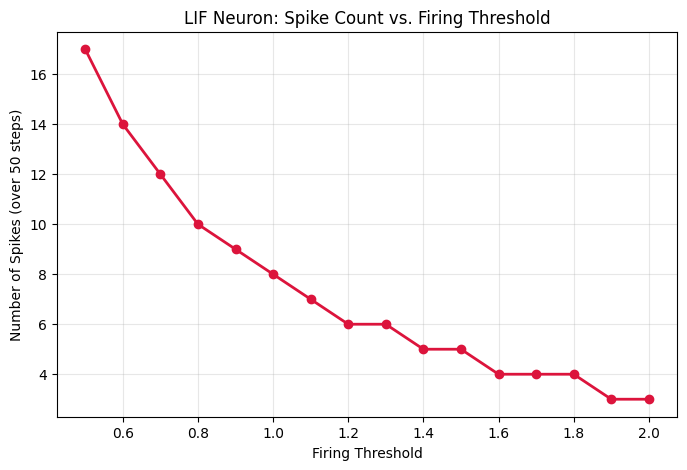

In [ ]:
!pip install snntorch
import snntorch as snn
import torch
import snntorch as snn
import torch

# one LIF neuron
beta = 0.95
threshold = 1.0
lif = snn.Leaky(beta=beta, threshold=threshold)

# fixed input: 0.2 current for 50 time steps
num_steps = 50
input_current = torch.ones(num_steps) * 0.2

# run the sim, count spikes
mem = torch.zeros(1)      # membrane potential starts at 0
spike_count = 0
for step in range(num_steps):
    spk, mem = lif(input_current[step], mem)
    spike_count += spk.item()

print(f"threshold {threshold}: {spike_count} spikes")
# sweep thresholds from 0.5 to 2.0
thresholds = [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 2.0]
spike_counts = []

for threshold in thresholds:
    lif = snn.Leaky(beta=beta, threshold=threshold)
    mem = torch.zeros(1)
    spikes_at_this_threshold = 0

    for step in range(num_steps):
        spk, mem = lif(input_current[step], mem)
        spikes_at_this_threshold += spk.item()

    spike_counts.append(spikes_at_this_threshold)
    print(f"threshold {threshold}: {spikes_at_this_threshold} spikes")
# sweep thresholds from 0.5 to 2.0
thresholds = torch.linspace(0.5, 2.0, 16)  # 16 different threshold values
spike_counts = []

for threshold in thresholds:
    lif = snn.Leaky(beta=beta, threshold=threshold)
    mem = torch.zeros(1)
    spikes_at_this_threshold = 0

    for step in range(num_steps):
        spk, mem = lif(input_current[step], mem)
        spikes_at_this_threshold += spk.item()

    spike_counts.append(spikes_at_this_threshold)
    print(f"threshold {threshold:.2f}: {spikes_at_this_threshold} spikes")

print(f"\nDone. Spike counts across thresholds: {spike_counts}")
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(thresholds.numpy(), spike_counts, marker='o', linewidth=2, color='crimson')
plt.xlabel("Firing Threshold")
plt.ylabel("Number of Spikes (over 50 steps)")
plt.title("LIF Neuron: Spike Count vs. Firing Threshold")
plt.grid(True, alpha=0.3)
plt.show()

